<a href="https://colab.research.google.com/github/saimanabila585-gif/Pothole-vs-Normal-Road-CNN/blob/main/Pothole_vs_Normal_Road_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# Pothole vs Normal Road Classification Using CNN
# Complete Google Colab Project
# ============================================================

# 1. Install / import libraries
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ============================================================
# 2. Download public dataset
# ============================================================
dataset_url = "https://zenodo.org/records/13334878/files/Normal%20pothole%20dataset.zip?download=1"

zip_path = "/content/normal_pothole_dataset.zip"
extract_path = "/content/normal_pothole_dataset"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    !wget -q --show-progress "{dataset_url}" -O "{zip_path}"
    print("Download complete!")
else:
    print("Dataset ZIP already exists.")

# Extract
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

# ============================================================
# 3. Find image folders automatically
# ============================================================

image_extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

normal_files = []
pothole_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(image_extensions):
            full_path = os.path.join(root, file)
            folder_name = os.path.basename(root).lower()

            if "pothole" in folder_name:
                pothole_files.append(full_path)

            elif "normal" in folder_name or "plain" in folder_name:
                normal_files.append(full_path)

print("Normal images found:", len(normal_files))
print("Pothole images found:", len(pothole_files))

# ============================================================
# 4. Create clean train/validation/test folders
# ============================================================

base_dir = "/content/pothole_project"

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

for folder in [
    train_dir, validation_dir, test_dir,
    os.path.join(train_dir, "normal"),
    os.path.join(train_dir, "pothole"),
    os.path.join(validation_dir, "normal"),
    os.path.join(validation_dir, "pothole"),
    os.path.join(test_dir, "normal"),
    os.path.join(test_dir, "pothole")
]:
    os.makedirs(folder, exist_ok=True)

# Use equal number of images from both classes
n = min(len(normal_files), len(pothole_files))
normal_files = random.sample(normal_files, n)
pothole_files = random.sample(pothole_files, n)

# 70% train, 15% validation, 15% test
normal_train, normal_temp = train_test_split(
    normal_files, test_size=0.30, random_state=42
)

normal_val, normal_test = train_test_split(
    normal_temp, test_size=0.50, random_state=42
)

pothole_train, pothole_temp = train_test_split(
    pothole_files, test_size=0.30, random_state=42
)

pothole_val, pothole_test = train_test_split(
    pothole_temp, test_size=0.50, random_state=42
)

def copy_images(files, destination):
    for i, src in enumerate(files):
        ext = os.path.splitext(src)[1]
        dst = os.path.join(destination, f"image_{i}{ext}")
        shutil.copy2(src, dst)

copy_images(normal_train, os.path.join(train_dir, "normal"))
copy_images(pothole_train, os.path.join(train_dir, "pothole"))

copy_images(normal_val, os.path.join(validation_dir, "normal"))
copy_images(pothole_val, os.path.join(validation_dir, "pothole"))

copy_images(normal_test, os.path.join(test_dir, "normal"))
copy_images(pothole_test, os.path.join(test_dir, "pothole"))

print("\nDataset prepared successfully!")

print("Training Normal:", len(os.listdir(os.path.join(train_dir, "normal"))))
print("Training Pothole:", len(os.listdir(os.path.join(train_dir, "pothole"))))

print("Validation Normal:", len(os.listdir(os.path.join(validation_dir, "normal"))))
print("Validation Pothole:", len(os.listdir(os.path.join(validation_dir, "pothole"))))

print("Testing Normal:", len(os.listdir(os.path.join(test_dir, "normal"))))
print("Testing Pothole:", len(os.listdir(os.path.join(test_dir, "pothole"))))

# ============================================================
# 5. Image preprocessing and augmentation
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

validation_generator = test_val_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

# ============================================================
# 6. VGG16 Transfer Learning Model
# ============================================================

conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
conv_base.trainable = False

model = models.Sequential([
    conv_base,

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 7. Train model
# ============================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks
)

# ============================================================
# 8. Test accuracy
# ============================================================

test_loss, test_accuracy = model.evaluate(test_generator)

print("\n==============================")
print("TEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("TEST LOSS:", round(test_loss, 4))
print("==============================")

# ============================================================
# 9. Accuracy and Loss curves
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# 10. Confusion Matrix
# ============================================================

test_generator.reset()

predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal Road", "Pothole"],
    yticklabels=["Normal Road", "Pothole"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["Normal Road", "Pothole"]
    )
)

# ============================================================
# 11. Sample predictions
# ============================================================

class_names = ["Normal Road", "Pothole"]

test_generator.reset()

images, labels = next(test_generator)

preds = model.predict(images)

plt.figure(figsize=(12,8))

for i in range(min(9, len(images))):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    predicted_label = class_names[int(preds[i] > 0.5)]
    actual_label = class_names[int(labels[i])]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 12. Save model
# ============================================================

model.save("/content/pothole_vs_normal_road_cnn.keras")

print("Model saved successfully!")

TensorFlow version: 2.20.0
GPU: []
/content/normal_pot 100%[===================>] 470.99M  2.63MB/s    in 3m 32s  
Download complete!
Extracting dataset...
Extraction complete!
Normal images found: 2500
Pothole images found: 2500

Dataset prepared successfully!
Training Normal: 1750
Training Pothole: 1750
Validation Normal: 375
Validation Pothole: 375
Testing Normal: 375
Testing Pothole: 375
Found 3500 images belonging to 2 classes.
Found 750 images belonging to 2 classes.
Found 750 images belonging to 2 classes.
Class mapping: {'normal': 0, 'pothole': 1}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2387s 22s/step - accuracy: 0.8809 - loss: 0.3296 - val_accuracy: 0.9413 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2306s 21s/step - accuracy: 0.9266 - loss: 0.1867 - val_accuracy: 0.9747 - val_loss: 0.0933 - learning_rate: 0.0010
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9333 - loss: 0.1654 

In [ ]:

print("Training history:")
print(history.history)

Training history:


NameError: name 'history' is not defined

In [ ]:

print("Dataset:", os.path.exists("/content/pothole_project"))
print("Train:", os.path.exists("/content/pothole_project/train"))
print("Test:", os.path.exists("/content/pothole_project/test"))

NameError: name 'os' is not defined

In [ ]:

import os

print("Dataset:", os.path.exists("/content/pothole_project"))
print("Train:", os.path.exists("/content/pothole_project/train"))
print("Test:", os.path.exists("/content/pothole_project/test"))

Dataset: False
Train: False
Test: False


In [ ]:

import os
import zipfile
import shutil
import random
from sklearn.model_selection import train_test_split

dataset_url = "https://zenodo.org/records/13334878/files/Normal%20pothole%20dataset.zip?download=1"

zip_path = "/content/normal_pothole_dataset.zip"
extract_path = "/content/normal_pothole_dataset"

!wget -q --show-progress "{dataset_url}" -O "{zip_path}"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

image_extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

normal_files = []
pothole_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(image_extensions):
            path = os.path.join(root, file)
            folder = os.path.basename(root).lower()

            if "pothole" in folder:
                pothole_files.append(path)
            elif "normal" in folder or "plain" in folder:
                normal_files.append(path)

print("Normal:", len(normal_files))
print("Pothole:", len(pothole_files))

/content/normal_pot 100%[===================>] 470.99M  1.18MB/s    in 4m 59s  
Normal: 2500
Pothole: 2500


In [ ]:

import os
import shutil
from sklearn.model_selection import train_test_split

base_dir = "/content/pothole_project"

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

for folder in [
    os.path.join(train_dir, "normal"),
    os.path.join(train_dir, "pothole"),
    os.path.join(validation_dir, "normal"),
    os.path.join(validation_dir, "pothole"),
    os.path.join(test_dir, "normal"),
    os.path.join(test_dir, "pothole")
]:
    os.makedirs(folder, exist_ok=True)

# 70% train, 15% validation, 15% test
normal_train, normal_temp = train_test_split(
    normal_files, test_size=0.30, random_state=42
)
normal_val, normal_test = train_test_split(
    normal_temp, test_size=0.50, random_state=42
)

pothole_train, pothole_temp = train_test_split(
    pothole_files, test_size=0.30, random_state=42
)
pothole_val, pothole_test = train_test_split(
    pothole_temp, test_size=0.50, random_state=42
)

def copy_images(files, destination):
    for i, src in enumerate(files):
        ext = os.path.splitext(src)[1]
        shutil.copy2(src, os.path.join(destination, f"image_{i}{ext}"))

copy_images(normal_train, os.path.join(train_dir, "normal"))
copy_images(pothole_train, os.path.join(train_dir, "pothole"))

copy_images(normal_val, os.path.join(validation_dir, "normal"))
copy_images(pothole_val, os.path.join(validation_dir, "pothole"))

copy_images(normal_test, os.path.join(test_dir, "normal"))
copy_images(pothole_test, os.path.join(test_dir, "pothole"))

print("Dataset prepared successfully!")
print("Training:", len(normal_train) + len(pothole_train))
print("Validation:", len(normal_val) + len(pothole_val))
print("Testing:", len(normal_test) + len(pothole_test))

Dataset prepared successfully!
Training: 3500
Validation: 750
Testing: 750


In [ ]:

# ============================================================
# Fast CNN Model - Pothole vs Normal Road
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Image preprocessing + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

validation_generator = test_val_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

# ============================================================
# CNN Architecture
# ============================================================

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# Training
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop]
)

print("Training completed successfully!")

Found 3500 images belonging to 2 classes.
Found 750 images belonging to 2 classes.
Found 750 images belonging to 2 classes.
Class mapping: {'normal': 0, 'pothole': 1}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6640 - loss: 0.6097 - val_accuracy: 0.8747 - val_loss: 0.3576
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8466 - loss: 0.3851 - val_accuracy: 0.9173 - val_loss: 0.2507
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8823 - loss: 0.3012 - val_accuracy: 0.7533 - val_loss: 0.5850
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9111 - loss: 0.2382 - val_accuracy: 0.7120 - val_loss: 0.7266
Training completed successfully!


In [ ]:

# ============================================================
# Final Test Evaluation
# ============================================================

test_loss, test_accuracy = model.evaluate(test_generator)

print("================================")
print("FINAL TEST ACCURACY:", round(test_accuracy * 100, 2), "%")
print("FINAL TEST LOSS:", round(test_loss, 4))
print("================================")

24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 404ms/step - accuracy: 0.9240 - loss: 0.2255
FINAL TEST ACCURACY: 92.4 %
FINAL TEST LOSS: 0.2255


24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 682ms/step


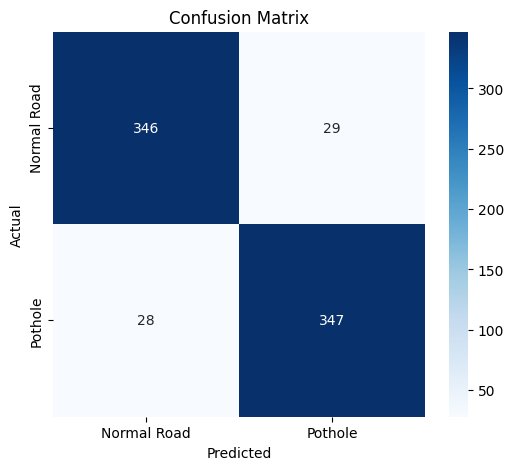

Classification Report:
              precision    recall  f1-score   support

 Normal Road       0.93      0.92      0.92       375
     Pothole       0.92      0.93      0.92       375

    accuracy                           0.92       750
   macro avg       0.92      0.92      0.92       750
weighted avg       0.92      0.92      0.92       750



In [ ]:

# ============================================================
# Confusion Matrix & Classification Report
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

test_generator.reset()

predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal Road", "Pothole"],
    yticklabels=["Normal Road", "Pothole"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["Normal Road", "Pothole"]
    )
)

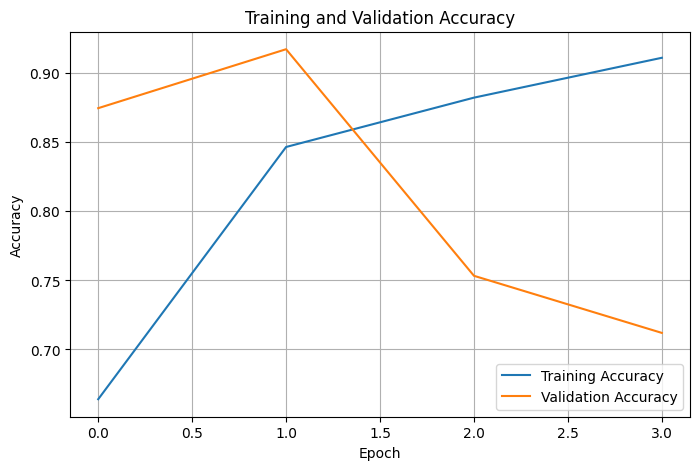

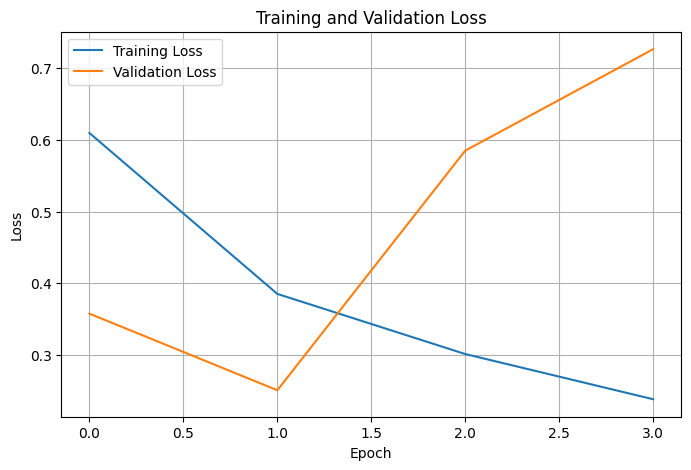

In [ ]:

# Accuracy and Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/tmp/ipykernel_1194/2548637016.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_label = class_names[int(predictions[i] > 0.5)]


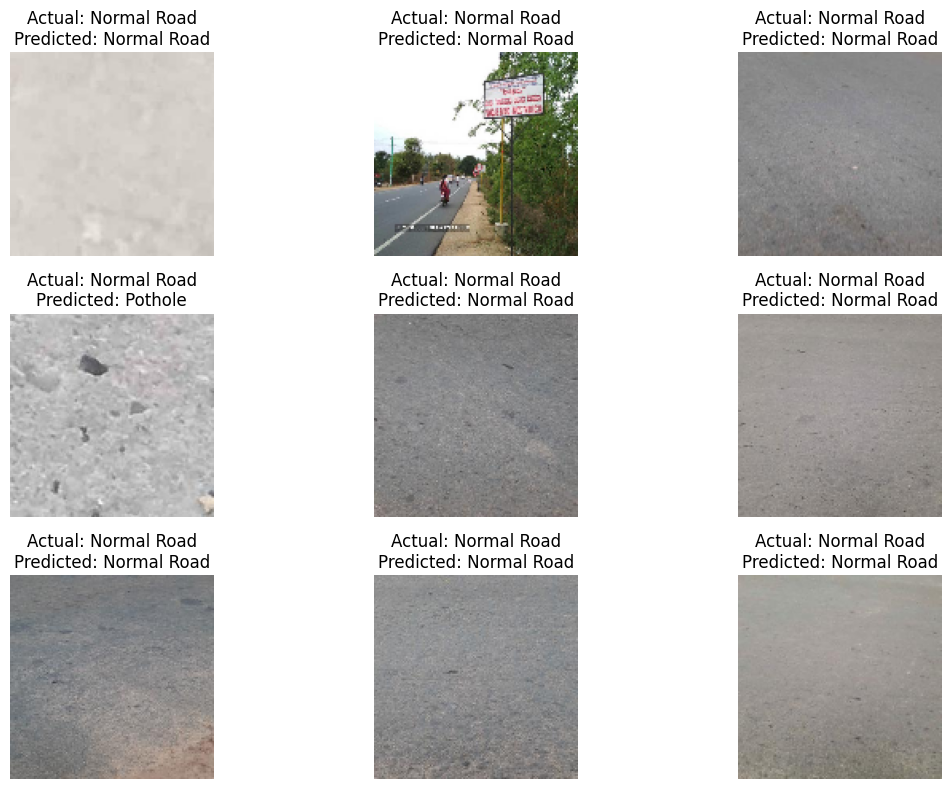

Sample prediction completed!
Model saved successfully!


In [ ]:

# ============================================================
# Sample Predictions + Save Model
# ============================================================

import matplotlib.pyplot as plt

class_names = ["Normal Road", "Pothole"]

test_generator.reset()

images, labels = next(test_generator)

predictions = model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    actual_label = class_names[int(labels[i])]
    predicted_label = class_names[int(predictions[i] > 0.5)]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Save trained model
model.save("/content/pothole_vs_normal_road_cnn.keras")

print("================================")
print("Sample prediction completed!")
print("Model saved successfully!")
print("================================")